In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dateutil.parser import parse as parse_date

Anomalies

In [177]:

# read in labels csv 
labels_df = pd.read_csv("C:\\Users\\angus\\OneDrive - University of Bristol\\mdm3_satellite\\satelite\\ESA-ADB-mdm\\data\\ESA-Mission1\\labels.csv",  parse_dates=["StartTime", "EndTime"], date_parser=lambda x: parse_date(x, ignoretz=True))

# read in anomaly_types csv 
anomaly_types_df = pd.read_csv("C:\\Users\\angus\\OneDrive - University of Bristol\\mdm3_satellite\\satelite\\ESA-ADB-mdm\\data\\ESA-Mission1\\anomaly_types.csv")


C:\Users\angus\AppData\Local\Temp\ipykernel_11052\849805809.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  labels_df = pd.read_csv("C:\\Users\\angus\\OneDrive - University of Bristol\\mdm3_satellite\\satelite\\ESA-ADB-mdm\\data\\ESA-Mission1\\labels.csv",  parse_dates=["StartTime", "EndTime"], date_parser=lambda x: parse_date(x, ignoretz=True))


In [178]:
print(labels_df.head())

     ID     Channel               StartTime                 EndTime
0  id_1  channel_12 2004-12-01 20:42:15.429 2004-12-08 22:55:45.429
1  id_1  channel_13 2004-12-01 20:42:15.429 2004-12-08 22:55:45.429
2  id_1  channel_14 2004-12-01 20:43:45.429 2004-12-02 02:57:15.429
3  id_1  channel_15 2004-12-01 20:45:00.429 2004-12-02 02:58:45.429
4  id_1  channel_16 2004-12-01 20:43:45.429 2004-12-16 16:52:30.429


In [179]:
# subset 41-46
subset_channels = ['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']

subset_labels_df = labels_df[labels_df['Channel'].isin(subset_channels)]

print(subset_labels_df.head())

      ID     Channel               StartTime                 EndTime
29  id_1  channel_41 2004-12-02 03:07:17.646 2004-12-08 23:35:55.146
30  id_1  channel_42 2004-12-02 03:07:17.646 2004-12-08 23:35:55.146
31  id_1  channel_43 2004-12-02 03:07:17.646 2004-12-08 23:35:55.146
32  id_1  channel_44 2004-12-02 03:07:17.646 2004-12-08 23:35:55.146
33  id_1  channel_45 2004-12-02 03:07:17.646 2004-12-08 23:35:55.146


In [180]:
for channel in subset_channels:
    channel_df = subset_labels_df[subset_labels_df['Channel'] == channel]
    unique_events = channel_df['ID'].unique()
    print(f"Channel: {channel}, Number of anomalies: {len(unique_events)}")

Channel: channel_41, Number of anomalies: 118
Channel: channel_42, Number of anomalies: 116
Channel: channel_43, Number of anomalies: 116
Channel: channel_44, Number of anomalies: 115
Channel: channel_45, Number of anomalies: 117
Channel: channel_46, Number of anomalies: 114


3 month processed data

In [181]:
# read csv

# path to desired processed dataset
three_month_train_path = "C:\\Users\\angus\\OneDrive - University of Bristol\\mdm3_satellite\\satelite\\ESA-ADB-mdm\\data\\preprocessed\\multivariate\\ESA-Mission1-semi-supervised\\3_months.train.csv"
ten_month_train_path = "C:\\Users\\angus\\OneDrive - University of Bristol\\mdm3_satellite\\satelite\\ESA-ADB-mdm\\data\\preprocessed\\multivariate\\ESA-Mission1-semi-supervised\\10_months.train.csv"

df = pd.read_csv(ten_month_train_path)

In [182]:
#print(df.head())

In [183]:
# subset 41-46
anomaly_subset = ['is_anomaly_' + channel for channel in subset_channels]


cols_to_keep = [
    c for c in df.columns
    if c in subset_channels or c in anomaly_subset or c == 'timestamp'
]

subset_df_temp = df[cols_to_keep]

subset_df = subset_df_temp.copy()

subset_df['timestamp'] = pd.to_datetime(subset_df['timestamp'])


print(subset_df.head())

            timestamp  channel_41  channel_42  channel_43  channel_44  \
0 2000-01-01 00:00:00    0.812578    0.786344    0.771900    0.799177   
1 2000-01-01 00:00:30    0.812578    0.786344    0.771900    0.799177   
2 2000-01-01 00:01:00    0.821213    0.789557    0.770317    0.809411   
3 2000-01-01 00:01:30    0.819642    0.786344    0.770317    0.807050   
4 2000-01-01 00:02:00    0.821996    0.788753    0.770317    0.807837   

   channel_45  channel_46  is_anomaly_channel_41  is_anomaly_channel_42  \
0    0.816855    0.765296                      0                      0   
1    0.816855    0.765296                      0                      0   
2    0.816006    0.765296                      0                      0   
3    0.816855    0.766985                      0                      0   
4    0.818551    0.761073                      0                      0   

   is_anomaly_channel_43  is_anomaly_channel_44  is_anomaly_channel_45  \
0                      0            

In [184]:
# printing df columns
for col in subset_df.columns:
    print(col)

timestamp
channel_41
channel_42
channel_43
channel_44
channel_45
channel_46
is_anomaly_channel_41
is_anomaly_channel_42
is_anomaly_channel_43
is_anomaly_channel_44
is_anomaly_channel_45
is_anomaly_channel_46


In [185]:
print(len(subset_df))

878401


In [186]:
# finding timestamp range
subset_df['timestamp'] = pd.to_datetime(subset_df['timestamp'])

start_time = subset_df['timestamp'].min()
end_time = subset_df['timestamp'].max()

print("Start:", start_time)
print("End:", end_time)


Start: 2000-01-01 00:00:00
End: 2000-11-01 00:00:00


In [187]:
# finding num anomalies in this timeperiod using labels

labels_in_timeperiod = subset_labels_df[(subset_labels_df['StartTime'] <= end_time) & (subset_labels_df['EndTime'] >= start_time)]

#print(labels_in_timeperiod)

unique_events = labels_in_timeperiod['ID'].unique()
print(f"Number of unique anomalies in time period: {len(unique_events)}")

for channel in subset_channels:
    channel_df = labels_in_timeperiod[labels_in_timeperiod['Channel'] == channel]
    unique_events_per_channel = channel_df['ID'].unique()
    print(f"Channel: {channel}, Number of unique anomalies in time period: {len(unique_events_per_channel)}")

Number of unique anomalies in time period: 9
Channel: channel_41, Number of unique anomalies in time period: 9
Channel: channel_42, Number of unique anomalies in time period: 9
Channel: channel_43, Number of unique anomalies in time period: 9
Channel: channel_44, Number of unique anomalies in time period: 9
Channel: channel_45, Number of unique anomalies in time period: 9
Channel: channel_46, Number of unique anomalies in time period: 9


Anomaly IDs in time period: ['id_22', 'id_23', 'id_35', 'id_59', 'id_151', 'id_167', 'id_185', 'id_193', 'id_200']
Plotting anomaly ID: id_200
Anomaly ID: id_200, Start: 2000-10-09 23:23:28.323000, End: 2000-10-11 05:46:58.323000, Length: 1 days 06:23:30


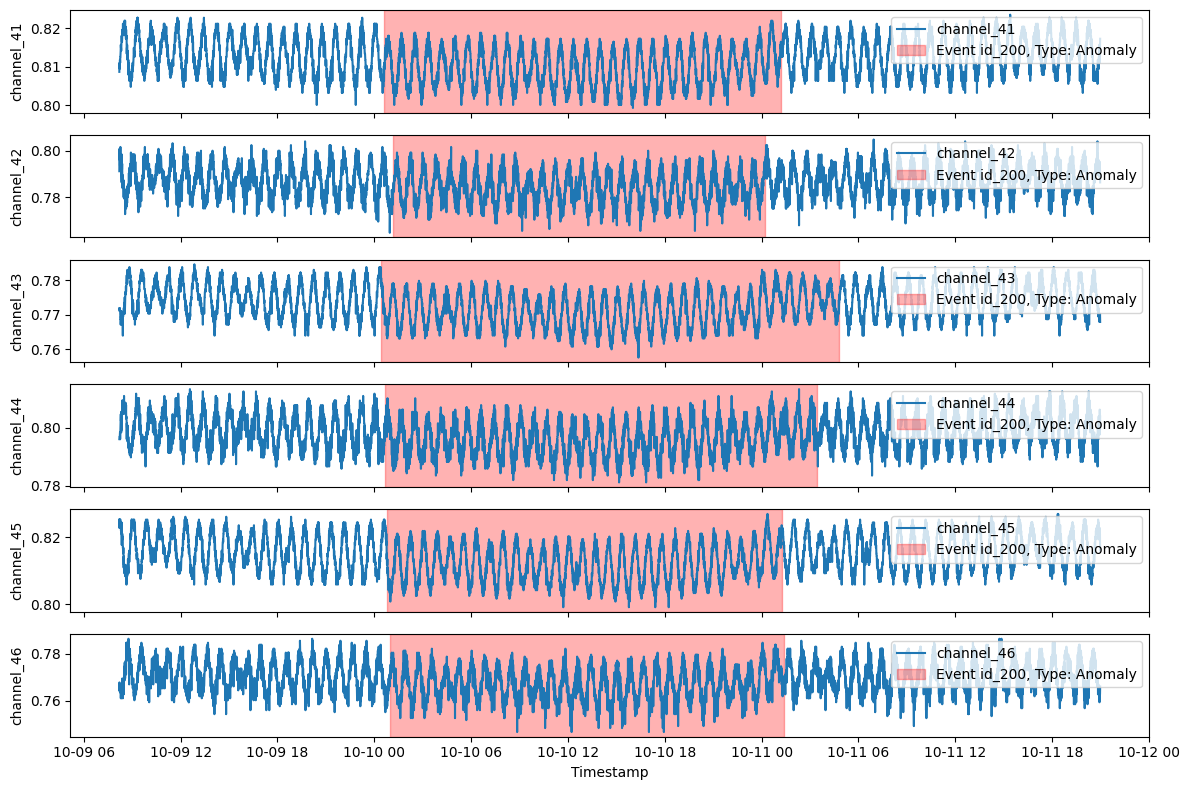

In [190]:
anomalies_ids_in_period = labels_in_timeperiod['ID'].unique().tolist()
print("Anomaly IDs in time period:", anomalies_ids_in_period)

def plotting_anomaly(subset_df, anomaly_subset, subset_channels, labels_in_timeperiod, target_anomaly_id = anomalies_ids_in_period[0]):

    # find anomalies with id in time period and find the corresponding time range
    target_anomaly_df = labels_in_timeperiod[labels_in_timeperiod['ID'] == target_anomaly_id]
    
    
    # find earliest start date and latest end date for this anomaly id
    anomaly_start_time = target_anomaly_df['StartTime'].min() - pd.Timedelta(hours=1)
    anomaly_end_time = target_anomaly_df['EndTime'].max() + pd.Timedelta(hours=1)

    anomaly_length = anomaly_end_time - anomaly_start_time

    print(f"Anomaly ID: {target_anomaly_id}, Start: {anomaly_start_time}, End: {anomaly_end_time}, Length: {anomaly_length}")

    anomaly_plot_start = anomaly_start_time - anomaly_length/2
    anomaly_plot_end = anomaly_end_time + anomaly_length/2


    # filter to the first anomaly day
    anomaly_df = subset_df[
        (subset_df['timestamp'] >= anomaly_plot_start) &
        (subset_df['timestamp'] <  anomaly_plot_end)
    ].copy()

    #for channel in anomaly_subset:
    #    print(channel, anomaly_df[channel].unique())

    anomaly_labels_df = labels_in_timeperiod[
        (labels_in_timeperiod['StartTime'] >= anomaly_plot_start) &
        (labels_in_timeperiod['EndTime'] <  anomaly_plot_end)
    ].copy()

    # create figure
    fig, axs = plt.subplots(
        len(subset_channels),
        1,
        figsize=(12, 8),
        sharex=True
    )

    # plotting anomaly in subset of channels
    for i, channel in enumerate(subset_channels):
        axs[i].plot(
            anomaly_df['timestamp'],
            anomaly_df[channel],
            label=channel
        )
        axs[i].set_ylabel(channel)
        axs[i].legend(loc='upper right')

        # shading 
        # non-zero mask for THIS column
        mask = anomaly_df['is_anomaly_'+ channel] != 0

        # find contiguous non-zero regions
        groups = (mask != mask.shift()).cumsum()

        # finding anomaly type for labelling on plot
        anomaly_type = anomaly_types_df[anomaly_types_df['ID'] == target_anomaly_id]['Category'].values[0]

        # ensures label only printed once for each anomaly region
        first = True

        for _, g in anomaly_df[mask].groupby(groups):
            axs[i].axvspan(
                g['timestamp'].iloc[0],
                g['timestamp'].iloc[-1],
                label=f'Event {target_anomaly_id}, Type: {anomaly_type}' if first else None,
                color='red',
                alpha=0.3
            )
            first = False

        axs[i].legend(loc='upper right')


        # shading anomaly regions based on labels data
        """for _, row in anomaly_labels_df.iterrows():

            start_time = row['StartTime']
            end_time = row['EndTime']
            channel_label = row['Channel']
            if channel_label == channel:
                axs[i].axvspan(
                    start_time,
                    end_time,
                    color='red',
                    alpha=0.3,
                    label = f'Anomaly {target_anomaly_id}: {anomaly_type}'
                )
                axs[i].legend(loc='upper right')"""

    axs[-1].set_xlabel("Timestamp")
    plt.tight_layout()
    plt.show()

# plot random anomaly
random_anomaly = np.random.choice(anomalies_ids_in_period)
print("Plotting anomaly ID:", random_anomaly)
plotting_anomaly(subset_df, anomaly_subset, subset_channels, labels_in_timeperiod, target_anomaly_id = random_anomaly)